# NASA CMAPSS + Fault CSV — Gaussian Naive Bayes Fault Detection
### Combined dataset approach: FaultCSV + CMAPSS (FD001–FD004)
### Binary target: Working (RUL > 30) · Broken (RUL ≤ 30)


## 1. Imports

In [1]:
from imblearn.over_sampling import SMOTE
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import os

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_validate, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, f1_score
)
from sklearn.base import clone
from scipy.stats import norm

SEED = 42
class_names = ['working', 'broken']
pd.set_option("display.max_rows", None)


## 2. Load Data
### 2a. Fault Detection CSV

In [2]:
csv_path = r"C:\Users\hamil\OneDrive\Desktop\UNI\Year 3\Year 3 Sem 1\ENGG2112\gas_turbine_fault_detection.csv"
data1 = pd.read_csv(csv_path)
print(f"FaultCSV shape: {data1.shape}")
print(data1.head())


FaultCSV shape: (1386, 10)
   Temperature (°C)           RPM  Torque (Nm)  Vibrations (mm/s)  \
0        924.835708  15650.870645  3464.645167           1.675087   
1        893.086785  15780.755598  3190.276340           2.042084   
2        932.384427  15016.002075  3401.769251           2.006414   
3        976.151493  14623.291065  3443.024901           2.239914   
4        888.292331  15229.986071  3448.764050           1.865677   

   Power Output (MW)  Fuel Flow Rate (kg/s)  Air Pressure (kPa)  \
0          96.347590               2.265294          146.245460   
1          83.288302               2.755950          166.812134   
2         120.358735               2.574244          133.494161   
3         104.689781               2.497101          140.141635   
4          95.080431               2.763689          109.795667   

   Exhaust Gas Temperature (°C)  Oil Temperature (°C)  Fault  
0                    517.611726             90.530958      0  
1                    500.1964

### 2b. CMAPSS (FD001–FD004 combined)

In [4]:
cols = ['unit', 'cycle', 'op_1', 'op_2', 'op_3',
        'T2','T24','T30','T50','P2','P15','P30','Nf','Nc','epr',
        'Ps30','phi','NRf','NRc','BPR','farB','htBleed',
        'Nf_dmd','PCNfR_dmd','W31','W32']

cmapss_path = r"C:\Users\hamil\OneDrive\Desktop\UNI\Year 3\Year 3 Sem 1\ENGG2112"   # ← update if your folder is elsewhere

dfs = []
for fd, offset in [('FD001', 0), ('FD002', 100), ('FD003', 360), ('FD004', 460)]:
    df = pd.read_csv(os.path.join(cmapss_path, f'train_{fd}.txt'),
                     sep=r'\s+', header=None, names=cols)
    df['unit']    = df['unit'] + offset   # avoid duplicate unit IDs across datasets
    df['dataset'] = fd
    dfs.append(df)

df_cmapss = pd.concat(dfs, ignore_index=True)

# Add RUL
df_cmapss['max_cycle'] = df_cmapss.groupby('unit')['cycle'].transform('max')
df_cmapss['RUL']       = df_cmapss['max_cycle'] - df_cmapss['cycle']

# Binary target: 0 = working (RUL > 30), 1 = broken (RUL <= 30)
df_cmapss['Engine_Condition'] = (df_cmapss['RUL'] <= 30).astype(int)

print(f"CMAPSS combined shape: {df_cmapss.shape}")
print("Class distribution:")
print(df_cmapss['Engine_Condition'].value_counts().rename({0:'working', 1:'broken'}))
df_cmapss.head()


CMAPSS combined shape: (160359, 30)
Class distribution:
Engine_Condition
working    138380
broken      21979
Name: count, dtype: int64


,unit,cycle,op_1,op_2,op_3,T2,T24,T30,T50,P2,...,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,dataset,max_cycle,RUL,Engine_Condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,0.03,392,2388,100.0,39.06,23.4190,FD001,192,191,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,0.03,392,2388,100.0,39.00,23.4236,FD001,192,190,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.03,390,2388,100.0,38.95,23.3442,FD001,192,189,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.03,392,2388,100.0,38.88,23.3739,FD001,192,188,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,0.03,393,2388,100.0,38.90,23.4044,FD001,192,187,0


## 3. Map to Common Feature Space
Both datasets are mapped to the same 4 physical features so they can be combined.

| Common name | FaultCSV column | CMAPSS column | Description |
|---|---|---|---|
| `Surface_Temperature` | `Surface_Temperature` | `T30` | HPC outlet temperature |
| `Exhaust_Temperature` | `Exhaust_Temperature` | `T50` | LPT outlet temperature |
| `Intake_Pressure` | `Intake_Pressure` | `P30` | HPC outlet pressure |
| `Exhaust_Pressure` | `Exhaust_Pressure` | `Ps30` | Static pressure at HPC |


In [5]:
# ── FaultCSV: rename columns to common names ─────────────────────────────
# Actual FaultCSV columns → common feature name mapping:
#   'Temperature (°C)'           → Surface_Temperature  (general engine temp ~ T30)
#   'Exhaust Gas Temperature (°C)'→ Exhaust_Temperature  (exhaust temp       ~ T50)
#   'Air Pressure (kPa)'         → Intake_Pressure      (air/intake pressure ~ P30)
#   'Oil Temperature (°C)'       → Exhaust_Pressure     (secondary thermal   ~ Ps30)

csv_col_map = {
    'Temperature (°C)':            'Surface_Temperature',
    'Exhaust Gas Temperature (°C)':'Exhaust_Temperature',
    'Air Pressure (kPa)':          'Intake_Pressure',
    'Oil Temperature (°C)':        'Exhaust_Pressure',
}
data1 = data1.rename(columns=csv_col_map)

# FaultCSV has binary Fault column (0/1) — map to 3-class Engine_Condition
# 0 (no fault) → 0 healthy,  1 (fault) → 2 critical
# FaultCSV Fault column: 0=working, 1=broken — maps directly to binary target
data1['Engine_Condition'] = data1['Fault'].map({0: 0, 1: 1})

feature_cols = ['Surface_Temperature', 'Exhaust_Temperature',
                'Intake_Pressure', 'Exhaust_Pressure']

# ── CMAPSS: map sensor names to common feature names ──────────────────────
df_mapped = pd.DataFrame({
    'Surface_Temperature': df_cmapss['T30'].values,
    'Exhaust_Temperature': df_cmapss['T50'].values,
    'Intake_Pressure':     df_cmapss['P30'].values,
    'Exhaust_Pressure':    df_cmapss['Ps30'].values,
    'Engine_Condition':    df_cmapss['Engine_Condition'].values,
})

print(f"FaultCSV features shape : {data1[feature_cols].shape}")
print(f"CMAPSS mapped shape     : {df_mapped[feature_cols].shape}")
print(f"\nFaultCSV Engine_Condition distribution:")
print(data1['Engine_Condition'].value_counts().rename({0:'working', 1:'broken'}))

FaultCSV features shape : (1386, 4)
CMAPSS mapped shape     : (160359, 4)

FaultCSV Engine_Condition distribution:
Engine_Condition
working    961
broken     425
Name: count, dtype: int64


## 4. Scale & Combine
Each dataset is MinMax-scaled **independently** before combining.  
This prevents CMAPSS's larger raw sensor ranges from dominating the merged feature space.


In [6]:
scaler_csv    = MinMaxScaler()
scaler_cmapss = MinMaxScaler()

csv_scaled    = scaler_csv.fit_transform(data1[feature_cols])
cmapss_scaled = scaler_cmapss.fit_transform(df_mapped[feature_cols])

df_csv_scaled = pd.DataFrame(csv_scaled, columns=feature_cols)
df_csv_scaled['Engine_Condition'] = data1['Engine_Condition'].values
df_csv_scaled['source'] = 'FaultCSV'

df_cmapss_scaled = pd.DataFrame(cmapss_scaled, columns=feature_cols)
df_cmapss_scaled['Engine_Condition'] = df_mapped['Engine_Condition'].values
df_cmapss_scaled['source'] = 'CMAPSS'

print(f"df_csv_scaled shape    : {df_csv_scaled.shape}")
print(f"df_cmapss_scaled shape : {df_cmapss_scaled.shape}")


df_csv_scaled shape    : (1386, 6)
df_cmapss_scaled shape : (160359, 6)


## 4. Scale & Combine
Each dataset is MinMax-scaled **independently** before combining.  
This prevents CMAPSS's larger raw sensor ranges from dominating the merged feature space.


In [7]:
# Combine and shuffle
df_combined = pd.concat([df_csv_scaled, df_cmapss_scaled], ignore_index=True)
df_combined = df_combined.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Combined shape: {df_combined.shape}")
print("\nClass distribution in combined dataset:")
print(df_combined['Engine_Condition'].value_counts()
      .rename({0:'working', 1:'broken'}))
print("\nSource breakdown:")
print(df_combined['source'].value_counts())
df_combined.head()

Combined shape: (161745, 6)

Class distribution in combined dataset:
Engine_Condition
working    139341
broken      22404
Name: count, dtype: int64

Source breakdown:
source
CMAPSS      160359
FaultCSV      1386
Name: count, dtype: int64


,Surface_Temperature,Exhaust_Temperature,Intake_Pressure,Exhaust_Pressure,Engine_Condition,source
0,0.941214,0.926171,0.958218,0.928743,0,CMAPSS
1,0.076876,0.079958,0.089936,0.077662,1,CMAPSS
2,0.926571,0.928134,0.958886,0.923139,0,CMAPSS
3,0.649102,0.538710,0.457390,0.662130,0,CMAPSS
4,0.624279,0.542660,0.455687,0.676541,0,CMAPSS


## 5. Exploratory Data Analysis

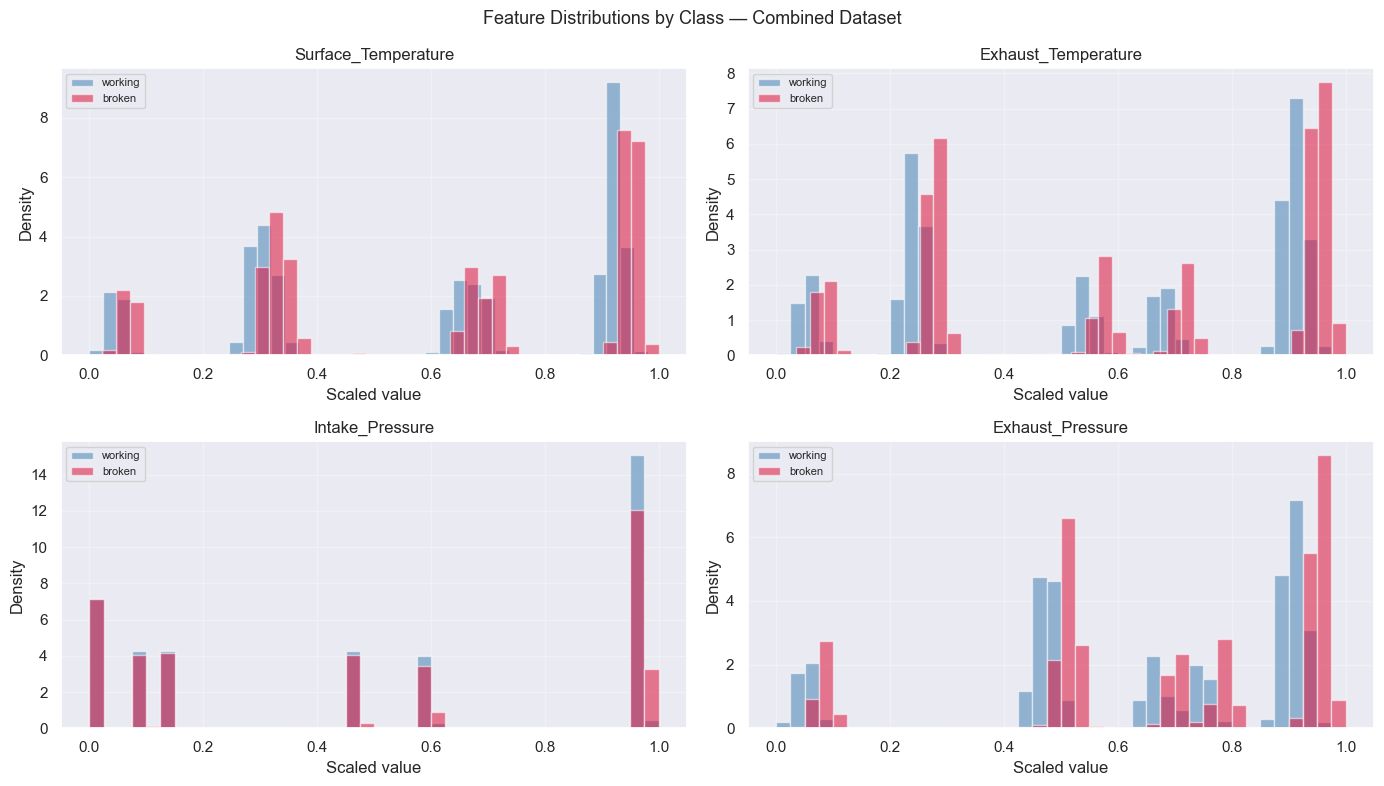

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ['steelblue', 'crimson']

for ax, feat in zip(axes.flatten(), feature_cols):
    for cls_idx, (cls_name, color) in enumerate(zip(class_names, colors)):
        subset = df_combined[df_combined['Engine_Condition'] == cls_idx][feat]
        subset.hist(bins=40, ax=ax, alpha=0.55, color=color, label=cls_name, density=True)
    ax.set_title(feat); ax.set_xlabel('Scaled value'); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Feature Distributions by Class — Combined Dataset', fontsize=13)
plt.tight_layout(); plt.show()


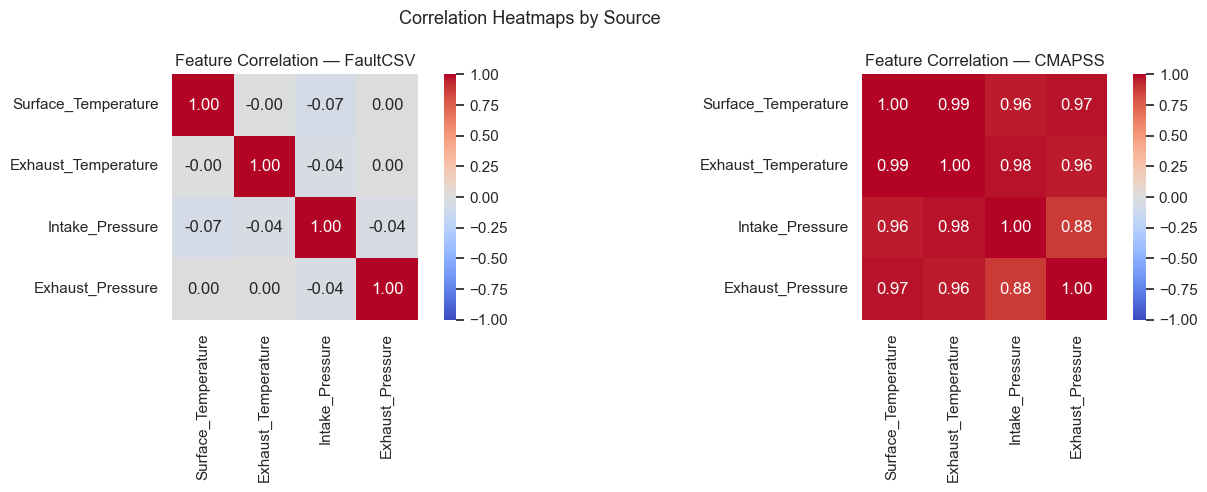

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, source in zip(axes, ['FaultCSV', 'CMAPSS']):
    subset = df_combined[df_combined['source'] == source][feature_cols]
    sns.heatmap(subset.corr(), annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title(f'Feature Correlation — {source}')

plt.suptitle('Correlation Heatmaps by Source', fontsize=13)
plt.tight_layout(); plt.show()


## 6. Train / Test Split

In [10]:
X = df_combined.drop(['Engine_Condition', 'source'], axis=1)
y = df_combined['Engine_Condition']

# 75/25 split — matching the Random Forest approach
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.75, random_state=10
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print("\nClass distribution BEFORE SMOTE:")
print(pd.Series(y_train).value_counts().rename({0:'working', 1:'broken'}))

# ── SMOTE ─────────────────────────────────────────────────────────────────
# Majority of data is healthy (no fault). SMOTE generates synthetic minority
# class samples so GNB sees balanced training data — same approach as RF model.
# Applied to training data ONLY to avoid data leakage into the test set.
smote = SMOTE(random_state=SEED)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train).value_counts().rename({0:'working', 1:'broken'}))
print(f"\nX_train after SMOTE: {X_train.shape}")

# Convert back to numpy for sklearn compatibility
X_train = np.array(X_train)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_test  = np.array(y_test)

X_train: (121308, 4)  |  X_test: (40437, 4)

Class distribution BEFORE SMOTE:
Engine_Condition
working    104535
broken      16773
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Engine_Condition
working    104535
broken     104535
Name: count, dtype: int64

X_train after SMOTE: (209070, 4)


## 7. Train Gaussian Naive Bayes

In [11]:
gnb = GaussianNB(var_smoothing=1e-9)
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)
print(f"GaussianNB accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names))


GaussianNB accuracy: 0.5106

              precision    recall  f1-score   support

     working       0.88      0.50      0.64     34806
      broken       0.16      0.58      0.25      5631

    accuracy                           0.51     40437
   macro avg       0.52      0.54      0.44     40437
weighted avg       0.78      0.51      0.58     40437



## 8. Confusion Matrix

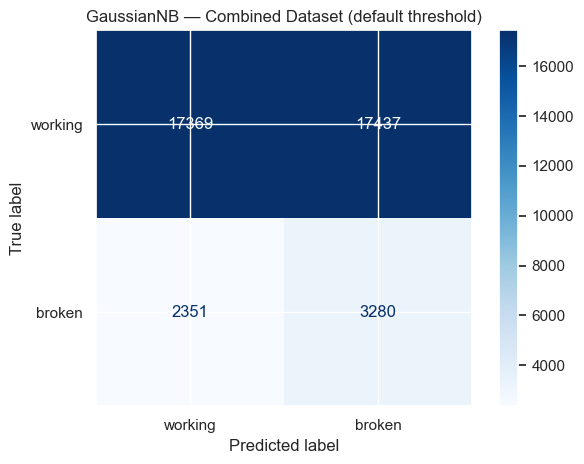

Critical-class recall: 0.0000


c:\Users\hamil\anaconda3\envs\phys2912\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap='Blues')
plt.title('GaussianNB — Combined Dataset (default threshold)')
plt.tight_layout(); plt.show()

critical_recall = recall_score(y_test, y_pred, labels=[2], average='macro')
print(f"Critical-class recall: {critical_recall:.4f}")


## 9. Hyperparameter Sweep — `var_smoothing`

Best var_smoothing: 1.00e-11  →  accuracy: 0.5106


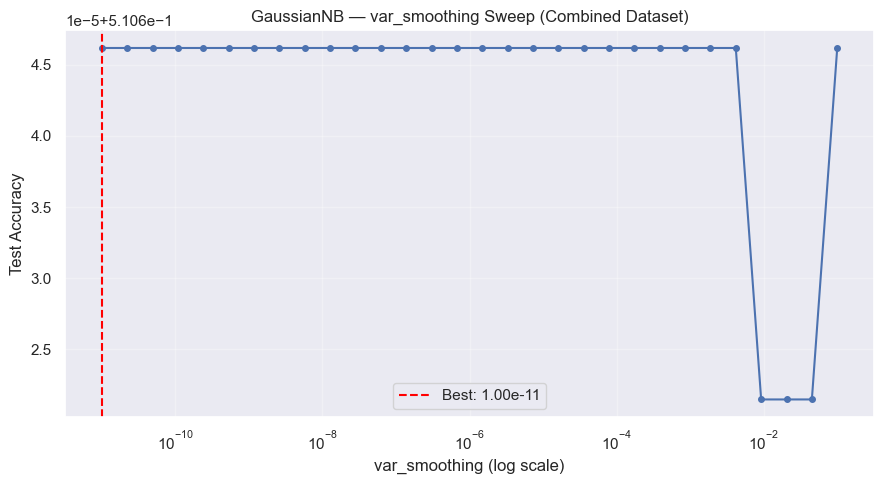


Final accuracy (best var_smoothing=1.00e-11): 0.5106
              precision    recall  f1-score   support

     working       0.88      0.50      0.64     34806
      broken       0.16      0.58      0.25      5631

    accuracy                           0.51     40437
   macro avg       0.52      0.54      0.44     40437
weighted avg       0.78      0.51      0.58     40437



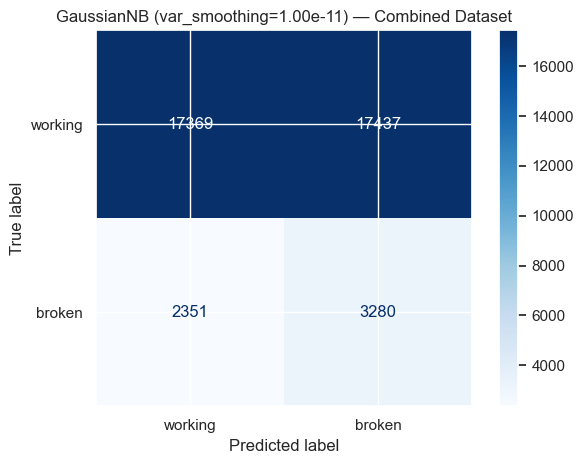

In [13]:
smoothing_values = np.logspace(-11, -1, 30)
accuracies = []

for vs in smoothing_values:
    m = GaussianNB(var_smoothing=vs)
    m.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, m.predict(X_test)))

best_vs  = smoothing_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"Best var_smoothing: {best_vs:.2e}  →  accuracy: {best_acc:.4f}")

plt.figure(figsize=(9, 5))
plt.semilogx(smoothing_values, accuracies, marker='o', markersize=4)
plt.axvline(best_vs, color='red', linestyle='--', label=f'Best: {best_vs:.2e}')
plt.xlabel('var_smoothing (log scale)'); plt.ylabel('Test Accuracy')
plt.title('GaussianNB — var_smoothing Sweep (Combined Dataset)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Retrain with best smoothing
gnb_best = GaussianNB(var_smoothing=best_vs)
gnb_best.fit(X_train, y_train)
y_pred_best = gnb_best.predict(X_test)

print(f"\nFinal accuracy (best var_smoothing={best_vs:.2e}): {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best, target_names=class_names))

cm_best = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=class_names).plot(cmap='Blues')
plt.title(f'GaussianNB (var_smoothing={best_vs:.2e}) — Combined Dataset')
plt.tight_layout(); plt.show()


## 10. Threshold Tuning for Critical Recall

Class order: [0 1]

--- broken threshold = 0.35 ---
              precision    recall  f1-score   support

     working       0.00      0.00      0.00     34806
      broken       0.14      1.00      0.24      5631

    accuracy                           0.14     40437
   macro avg       0.07      0.50      0.12     40437
weighted avg       0.02      0.14      0.03     40437



c:\Users\hamil\anaconda3\envs\phys2912\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hamil\anaconda3\envs\phys2912\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hamil\anaconda3\envs\phys2912\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

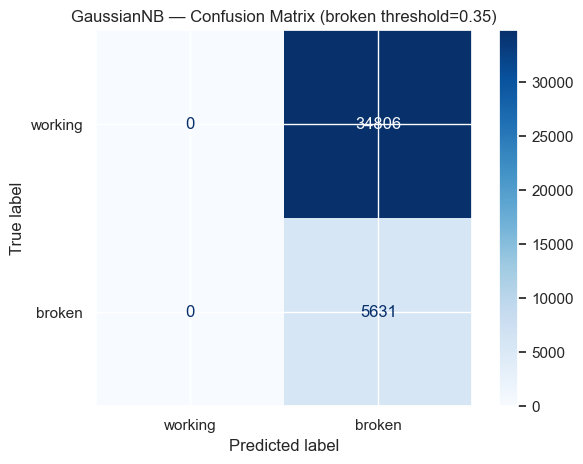

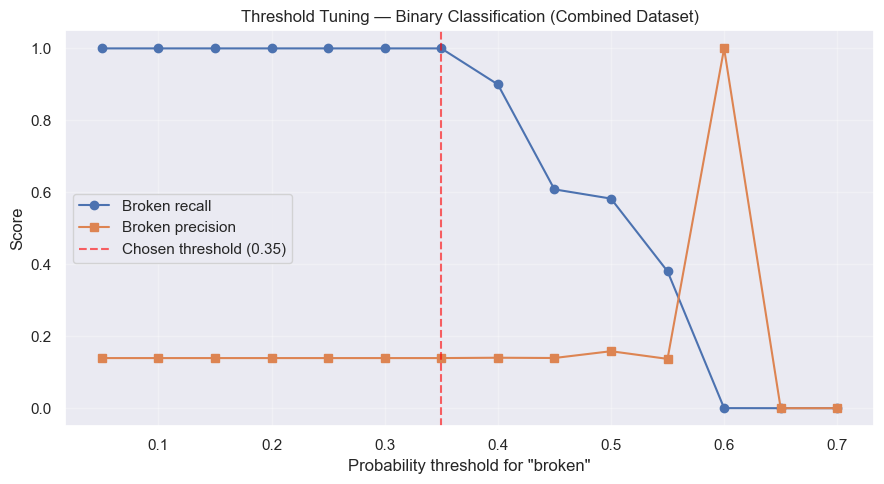

In [14]:
y_proba = gnb_best.predict_proba(X_test)
print(f"Class order: {gnb_best.classes_}")   # should be [0 1]

# ── Threshold tuning ──────────────────────────────────────────────────────
# Lower threshold → catch more broken engines (higher recall, lower precision)
threshold_broken = 0.35
y_adj = (y_proba[:, 1] > threshold_broken).astype(int)

print(f"\n--- broken threshold = {threshold_broken} ---")
print(classification_report(y_test, y_adj, target_names=class_names))

cm_adj = confusion_matrix(y_test, y_adj)
ConfusionMatrixDisplay(confusion_matrix=cm_adj, display_labels=class_names).plot(cmap='Blues')
plt.title(f'GaussianNB — Confusion Matrix (broken threshold={threshold_broken})')
plt.tight_layout(); plt.show()

# ── Threshold sweep ───────────────────────────────────────────────────────
thresholds  = np.arange(0.05, 0.75, 0.05)
recalls, precisions = [], []
for t in thresholds:
    y_tmp = (y_proba[:, 1] > t).astype(int)
    recalls.append(recall_score(y_test, y_tmp, pos_label=1))
    precisions.append(precision_score(y_test, y_tmp, pos_label=1, zero_division=0))

plt.figure(figsize=(9, 5))
plt.plot(thresholds, recalls,    marker='o', label='Broken recall')
plt.plot(thresholds, precisions, marker='s', label='Broken precision')
plt.axvline(threshold_broken, color='red', linestyle='--', alpha=0.6,
            label=f'Chosen threshold ({threshold_broken})')
plt.xlabel('Probability threshold for "broken"'); plt.ylabel('Score')
plt.title('Threshold Tuning — Binary Classification (Combined Dataset)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 11. Cross-Validation
We compare **Standard K-Fold** vs **Stratified K-Fold** (k=5) on the combined dataset.


In [15]:
K       = 5
scoring = ['accuracy', 'f1_macro']
gnb_cv  = GaussianNB(var_smoothing=best_vs)

kf  = KFold(n_splits=K, shuffle=True, random_state=SEED)
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

kf_results  = cross_validate(gnb_cv, X, y, cv=kf,  scoring=scoring)
skf_results = cross_validate(gnb_cv, X, y, cv=skf, scoring=scoring)

kf_acc  = kf_results['test_accuracy'];  kf_f1  = kf_results['test_f1_macro']
skf_acc = skf_results['test_accuracy']; skf_f1 = skf_results['test_f1_macro']

print("=" * 52)
print(f"  Standard K-Fold (k={K})")
print("=" * 52)
print(f"  Accuracy per fold : {kf_acc.round(4)}")
print(f"  Accuracy  mean ± std : {kf_acc.mean():.4f} ± {kf_acc.std():.4f}")
print(f"  F1-macro  mean ± std : {kf_f1.mean():.4f} ± {kf_f1.std():.4f}")
print()
print("=" * 52)
print(f"  Stratified K-Fold (k={K})")
print("=" * 52)
print(f"  Accuracy per fold : {skf_acc.round(4)}")
print(f"  Accuracy  mean ± std : {skf_acc.mean():.4f} ± {skf_acc.std():.4f}")
print(f"  F1-macro  mean ± std : {skf_f1.mean():.4f} ± {skf_f1.std():.4f}")


  Standard K-Fold (k=5)
  Accuracy per fold : [0.8607 0.8638 0.8607 0.8593 0.8628]
  Accuracy  mean ± std : 0.8615 ± 0.0016
  F1-macro  mean ± std : 0.4628 ± 0.0005

  Stratified K-Fold (k=5)
  Accuracy per fold : [0.8615 0.8615 0.8615 0.8615 0.8615]
  Accuracy  mean ± std : 0.8615 ± 0.0000
  F1-macro  mean ± std : 0.4628 ± 0.0000


### 11.1 Fold-by-Fold Comparison

C:\Users\hamil\AppData\Local\Temp\ipykernel_64668\867475871.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([kf_acc, skf_acc],


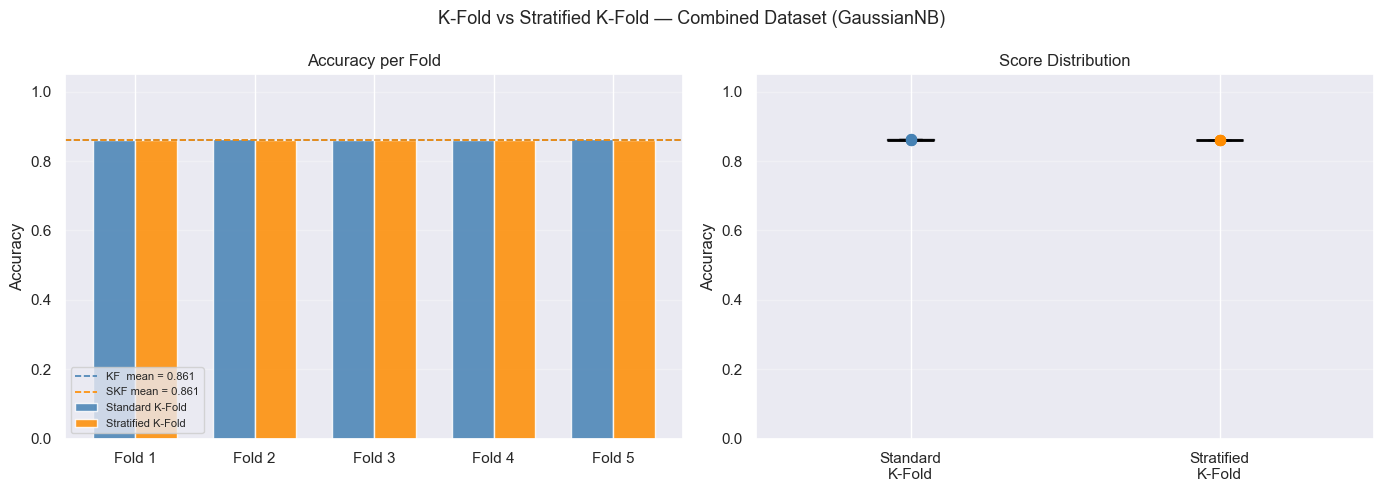

In [16]:
fold_labels = [f'Fold {i+1}' for i in range(K)]
x = np.arange(K); width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(x - width/2, kf_acc,  width, label='Standard K-Fold',   color='steelblue',  alpha=0.85)
ax.bar(x + width/2, skf_acc, width, label='Stratified K-Fold', color='darkorange', alpha=0.85)
ax.axhline(kf_acc.mean(),  color='steelblue',  linestyle='--', linewidth=1.2,
           label=f'KF  mean = {kf_acc.mean():.3f}')
ax.axhline(skf_acc.mean(), color='darkorange', linestyle='--', linewidth=1.2,
           label=f'SKF mean = {skf_acc.mean():.3f}')
ax.set_xticks(x); ax.set_xticklabels(fold_labels)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
ax.set_title('Accuracy per Fold'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bp = ax2.boxplot([kf_acc, skf_acc],
                 labels=['Standard\nK-Fold', 'Stratified\nK-Fold'],
                 patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue');  bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('darkorange'); bp['boxes'][1].set_alpha(0.7)
ax2.scatter([1]*K, kf_acc,  color='steelblue',  zorder=5, s=50)
ax2.scatter([2]*K, skf_acc, color='darkorange', zorder=5, s=50)
ax2.set_ylabel('Accuracy'); ax2.set_ylim(0, 1.05)
ax2.set_title('Score Distribution'); ax2.grid(axis='y', alpha=0.3)

plt.suptitle('K-Fold vs Stratified K-Fold — Combined Dataset (GaussianNB)', fontsize=13)
plt.tight_layout(); plt.show()


### 11.2 Per-Class F1 Across Folds (Stratified)

In [17]:
f1_per_class = {cls: [] for cls in class_names}

for train_idx, val_idx in skf.split(X, y):
    m = clone(gnb_cv)
    m.fit(X[train_idx], y[train_idx])
    f1s = f1_score(y[val_idx], m.predict(X[val_idx]), average=None, labels=[0, 1])
    for cls_idx, cls_name in enumerate(class_names):
        f1_per_class[cls_name].append(f1s[cls_idx])

colors_cls = ['steelblue', 'crimson']
plt.figure(figsize=(10, 5))
for cls_name, color in zip(class_names, colors_cls):
    vals = np.array(f1_per_class[cls_name])
    plt.plot(fold_labels, vals, marker='o', color=color, label=cls_name, linewidth=2)
    plt.axhline(vals.mean(), color=color, linestyle=':', linewidth=1,
                label=f'{cls_name} mean = {vals.mean():.3f}')
plt.ylabel('F1 Score'); plt.ylim(0, 1.05)
plt.title('Per-Class F1 per Fold — Stratified K-Fold (Combined Dataset)')
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


KeyError: "None of [Index([     0,      1,      2,      3,      5,      6,      7,      8,      9,\n           10,\n       ...\n       161735, 161736, 161737, 161738, 161739, 161740, 161741, 161742, 161743,\n       161744],\n      dtype='int64', length=129396)] are in the [columns]"

### 11.3 Summary Table

In [ ]:
summary = pd.DataFrame({
    'Method': ['Standard K-Fold', 'Stratified K-Fold', 'Hold-out Test Set'],
    'Accuracy (mean)': [
        f"{kf_acc.mean():.4f}", f"{skf_acc.mean():.4f}",
        f"{accuracy_score(y_test, y_pred_best):.4f}"
    ],
    'Accuracy (std)': [
        f"± {kf_acc.std():.4f}", f"± {skf_acc.std():.4f}", "N/A"
    ],
    'F1-macro (mean)': [
        f"{kf_f1.mean():.4f}", f"{skf_f1.mean():.4f}",
        f"{f1_score(y_test, y_pred_best, average='macro'):.4f}"
    ],
    'F1-macro (std)': [
        f"± {kf_f1.std():.4f}", f"± {skf_f1.std():.4f}", "N/A"
    ]
})
print(summary.to_string(index=False))


## 12. Learned Gaussian Distributions per Class

In [ ]:
x_range = np.linspace(-0.5, 1.5, 400)
colors  = ['steelblue', 'crimson']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat_idx, feat_name in zip(axes, range(4), feature_cols):
    for cls_idx, cls_name in enumerate(class_names):
        mu  = gnb_best.theta_[cls_idx, feat_idx]
        sig = np.sqrt(gnb_best.var_[cls_idx, feat_idx])
        ax.plot(x_range, norm.pdf(x_range, mu, sig),
                color=colors[cls_idx], label=cls_name, linewidth=2)
    ax.set_title(feat_name, fontsize=10)
    ax.set_xlabel('Scaled value'); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Learned Gaussian Distributions — Working vs Broken (Combined Dataset)',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## 13. Source Contribution Analysis
How well does the model perform on each source separately?  
This reveals whether one dataset is harder to classify than the other.


In [ ]:
# Re-attach source labels to the test split (need indices before shuffling)
df_combined_indexed = df_combined.copy()
df_combined_indexed['_original_idx'] = df_combined_indexed.index

# Rebuild split with same random state to recover test indices
_, X_test_raw, _, y_test_raw, _, idx_test = train_test_split(
    df_combined[feature_cols].values,
    df_combined['Engine_Condition'].values,
    df_combined.index,
    test_size=0.2, random_state=SEED,
    stratify=df_combined['Engine_Condition'].values
)

test_sources = df_combined.loc[idx_test, 'source'].values

for src in ['FaultCSV', 'CMAPSS']:
    mask = test_sources == src
    if mask.sum() == 0:
        continue
    acc = accuracy_score(y_test_raw[mask], y_pred_best[mask])
    print(f"\n{'='*45}")
    print(f"  Source: {src}  ({mask.sum()} test samples)")
    print(f"{'='*45}")
    print(f"  Accuracy: {acc:.4f}")
    print(classification_report(y_test_raw[mask], y_pred_best[mask],
                                 target_names=class_names))
